# Semantic Book Intelligence Research Lab
## Notebook 03 — Building Better Representations of Books (Iteration 1)

Objective: Engineer structured features and export `book_features_v1.parquet`.

## FEATURE ENGINEERING and INITIAL Model training/testing (PART - 1)

In [6]:
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures

PROJECT_ROOT=Path.cwd().parent if Path.cwd().name=="notebooks" else Path.cwd()

INTERIM=PROJECT_ROOT/"data"/"interim"; PROCESSED=PROJECT_ROOT/"data"/"processed"; REPORTS=PROJECT_ROOT/"reports"
PROCESSED.mkdir(parents=True,exist_ok=True)

books=pd.read_parquet(INTERIM/"books_sample.parquet")

books.head()

,isbn,text_reviews_count,country_code,language_code,asin,is_ebook,average_rating,kindle_asin,description,format,...,has_description,description_length_chars,has_page_count,page_count_zero,page_count_nonpositive,publication_year_plausible,author_count,series_count,popular_shelf_count,similar_book_count
0,0307276457,23,US,NaN,<NA>,False,3.96,B000W914CM,National Bestseller\nAcclaimed historian Josep...,Paperback,...,True,918,True,False,False,True,1,0,100,17
1,1400115701,1,US,NaN,<NA>,False,3.82,<NA>,"Decades before The Daily Show, The Smothers Br...",Audio CD,...,True,1299,True,True,True,True,2,0,100,17
2,<NA>,1,US,spa,<NA>,False,2.00,<NA>,Un hombre recien salido de prision debe encont...,Paperback,...,True,109,True,False,False,True,1,0,0,0
3,1410472795,5,US,NaN,<NA>,False,3.70,B00FJ3AAWQ,'Elizabeth is missing.' Maud keeps finding not...,Hardcover,...,True,1382,True,False,False,True,1,0,100,18
4,<NA>,1,US,por,<NA>,False,4.34,<NA>,Kurumi pediu a ajuda da Sawako para conquistar...,Paperback,...,True,212,True,False,False,True,1,1,100,3


In [8]:
candidate_columns = [
    "publication_year",
    "original_publication_year",
    "publication_year_valid",
    "publication_year_plausible",
    "num_pages",
    "num_pages_clean",
    "has_page_count",
    "page_count_zero",
    "page_count_nonpositive",
]

[c for c in candidate_columns if c in books.columns]

['publication_year',
 'publication_year_plausible',
 'num_pages',
 'has_page_count',
 'page_count_zero',
 'page_count_nonpositive']

In [15]:

features = books.copy()

# Goodreads Book Graph was collected around 2017.
# Using a fixed reference year keeps the feature reproducible.
REFERENCE_YEAR = 2017

# Clean page-count feature

if "num_pages_clean" not in features.columns:

    if "num_pages" not in features.columns:
        raise KeyError(
            "Cannot create num_pages_clean because num_pages is unavailable."
        )

    features["num_pages_clean"] = pd.to_numeric(
        features["num_pages"],
        errors="coerce"
    )

    # Zero and negative page counts are not meaningful book lengths.
    features.loc[
        features["num_pages_clean"] <= 0,
        "num_pages_clean"
    ] = np.nan


# Edition-age feature

if "edition_age" not in features.columns:

    if "publication_year" not in features.columns:
        raise KeyError(
            "Cannot create edition_age because publication_year is unavailable."
        )

    publication_year = pd.to_numeric(
        features["publication_year"],
        errors="coerce"
    )

    if "publication_year_plausible" in features.columns:
        publication_year = publication_year.where(
            features["publication_year_plausible"].fillna(False)
        )

    # Avoid impossible negative ages relative to the dataset snapshot.
    publication_year = publication_year.where(
        publication_year <= REFERENCE_YEAR
    )

    features["edition_age"] = REFERENCE_YEAR - publication_year


In [16]:
features[
    [
        "num_pages",
        "num_pages_clean",
        "publication_year",
        "edition_age"
    ]
].head()


,num_pages,num_pages_clean,publication_year,edition_age
0,304.0,304.0,2008.0,9.0
1,0.0,NaN,2010.0,7.0
2,254.0,254.0,1965.0,52.0
3,455.0,455.0,2014.0,3.0
4,208.0,208.0,2011.0,6.0


In [17]:
features[
    [
        "num_pages_clean",
        "edition_age",
    ]
].describe()


,num_pages_clean,edition_age
count,3365.000000,3720.000000
mean,271.557801,10.548925
std,229.503285,16.351026
min,1.000000,0.000000
25%,151.000000,3.000000
50%,246.000000,6.000000
75%,347.000000,13.000000
max,4683.000000,595.000000


In [23]:
# Create the log features

log_columns = [
    "ratings_count",
    "text_reviews_count",
    "num_pages_clean",
    "description_length_chars",
]

for column in log_columns:

    numeric_values = pd.to_numeric(
        features[column],
        errors="coerce"
    )

    # log1p requires values greater than or equal to zero.
    numeric_values = numeric_values.clip(lower=0)

    features[f"log1p_{column}"] = np.log1p(numeric_values)

In [26]:
features.filter(regex=r"^log1p_").columns.tolist()

['log1p_ratings_count',
 'log1p_text_reviews_count',
 'log1p_num_pages_clean',
 'log1p_description_length_chars']

In [36]:
# Create the polynomial features

poly_inputs = [
    "edition_age",
    "num_pages_clean",
    "description_length_chars",
]

poly = PolynomialFeatures(
    degree=2,
    include_bias=False
)

poly_values = poly.fit_transform(
    features[poly_inputs].fillna(0)
)

poly_df = pd.DataFrame(
    poly_values,
    columns=poly.get_feature_names_out(poly_inputs),
    index=features.index,
)

# Retain only genuinely new features.
poly_df = poly_df.loc[
    :,
    ~poly_df.columns.isin(features.columns)
]

display(poly_df.head())

print("Polynomial features:")
for column in poly_df.columns:
    print(f"  - {column}")

,edition_age^2,edition_age num_pages_clean,edition_age description_length_chars,num_pages_clean^2,num_pages_clean description_length_chars,description_length_chars^2
0,81.0,2736.0,8262.0,92416.0,279072.0,842724.0
1,49.0,0.0,9093.0,0.0,0.0,1687401.0
2,2704.0,13208.0,5668.0,64516.0,27686.0,11881.0
3,9.0,1365.0,4146.0,207025.0,628810.0,1909924.0
4,36.0,1248.0,1272.0,43264.0,44096.0,44944.0


Polynomial features:
  - edition_age^2
  - edition_age num_pages_clean
  - edition_age description_length_chars
  - num_pages_clean^2
  - num_pages_clean description_length_chars
  - description_length_chars^2


In [39]:
# Create interaction features

features["edition_age_x_log_ratings"] = (
    features["edition_age"]
    * features["log1p_ratings_count"]
)

features["description_length_x_pages"] = (
    features["description_length_chars"]
    * features["num_pages_clean"]
)


In [40]:
display(
    features.filter(regex=r"_x_").head()
)

,edition_age_x_log_ratings,description_length_x_pages
0,45.953509,279072.0
1,7.690286,NaN
2,36.043653,27686.0
3,6.238325,628810.0
4,10.750557,44096.0


In [45]:
# log transformations and cap indicators

features["popular_shelf_at_cap"] = (
    features["popular_shelf_count"] >= 100
).astype(int)

features["similar_book_at_cap"] = (
    features["similar_book_count"] >= 18
).astype(int)

features["relationship_richness"] = (
    np.log1p(features["author_count"].clip(lower=0))
    + np.log1p(features["series_count"].clip(lower=0))
    + np.log1p(features["popular_shelf_count"].clip(lower=0))
    + np.log1p(features["similar_book_count"].clip(lower=0))
)


In [46]:
features.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 46 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   isbn                            2965 non-null   string 
 1   text_reviews_count              5000 non-null   int64  
 2   country_code                    5000 non-null   str    
 3   language_code                   2715 non-null   str    
 4   asin                            992 non-null    string 
 5   is_ebook                        5000 non-null   boolean
 6   average_rating                  5000 non-null   float64
 7   kindle_asin                     2147 non-null   string 
 8   description                     4122 non-null   str    
 9   format                          3639 non-null   str    
 10  link                            5000 non-null   str    
 11  publisher                       3635 non-null   str    
 12  num_pages                       3381 non-null

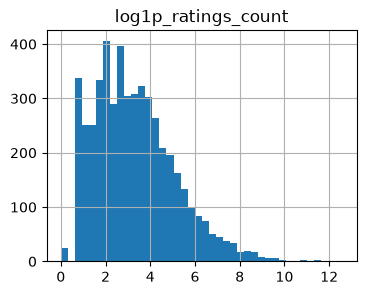

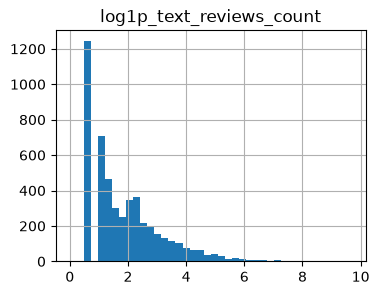

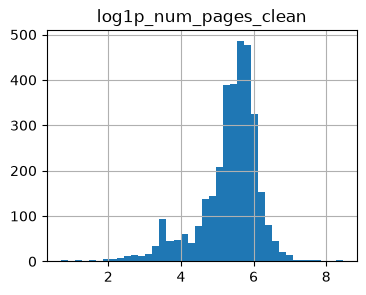

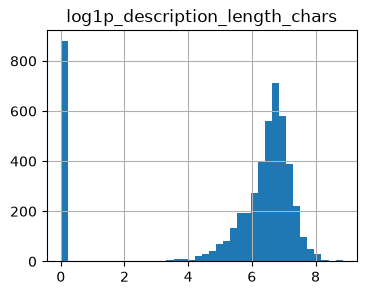

In [50]:
# Visualize log transformed features

for c in features.filter(regex='log1p').columns:
    plt.figure(figsize=(4,3));features[c].dropna().hist(bins=40);plt.title(c);plt.show()


In [56]:
#Creating Polynomial features

poly_inputs=[c for c in ["edition_age","num_pages_clean","description_length_chars"] if c in features.columns]

poly=PolynomialFeatures(degree=2,include_bias=False)

poly_df=pd.DataFrame(
    poly.fit_transform(features[poly_inputs].fillna(0)),
    columns=poly.get_feature_names_out(poly_inputs),
    index=features.index
)

display(poly_df.head())

,edition_age,num_pages_clean,description_length_chars,edition_age^2,edition_age num_pages_clean,edition_age description_length_chars,num_pages_clean^2,num_pages_clean description_length_chars,description_length_chars^2
0,9.0,304.0,918.0,81.0,2736.0,8262.0,92416.0,279072.0,842724.0
1,7.0,0.0,1299.0,49.0,0.0,9093.0,0.0,0.0,1687401.0
2,52.0,254.0,109.0,2704.0,13208.0,5668.0,64516.0,27686.0,11881.0
3,3.0,455.0,1382.0,9.0,1365.0,4146.0,207025.0,628810.0,1909924.0
4,6.0,208.0,212.0,36.0,1248.0,1272.0,43264.0,44096.0,44944.0


In [60]:
#Just check newly created interaction features

if {'edition_age','log1p_ratings_count'}.issubset(features.columns):
    features['editionAge_x_logRatings']=features['edition_age']*features['log1p_ratings_count']
    
if {'description_length_chars','num_pages_clean'}.issubset(features.columns):
    features['description_x_pages']=features['description_length_chars']*features['num_pages_clean']
    
display(features.filter(regex='_x_').head())

,edition_age_x_log_ratings,description_length_x_pages,editionAge_x_logRatings,description_x_pages
0,45.953509,279072.0,45.953509,279072.0
1,7.690286,NaN,7.690286,NaN
2,36.043653,27686.0,36.043653,27686.0
3,6.238325,628810.0,6.238325,628810.0
4,10.750557,44096.0,10.750557,44096.0


In [66]:
# Explore book metadata features

features['metadata_completeness_score']=0

for c in ['description','publisher','language_code','isbn13','num_pages_clean']:
    if c in features.columns:
        features['metadata_completeness_score']+=features[c].notna().astype(int)

if {'log1p_ratings_count','log1p_text_reviews_count'}.issubset(features.columns):
    features['popularity_index']=features['log1p_ratings_count']+features['log1p_text_reviews_count']

rel=[c for c in ['author_count','series_count','popular_shelf_count','similar_book_count'] if c in features.columns]

features['relationship_richness']=features[rel].sum(axis=1)

display(features[['metadata_completeness_score','popularity_index','relationship_richness']].head())


,metadata_completeness_score,popularity_index,relationship_richness
0,4,8.283999,118
1,3,1.791759,119
2,4,1.386294,1
3,4,3.871201,119
4,4,2.484907,105


In [73]:
# adding both count and proportion

metadata_fields = [
    "description",
    "publisher",
    "language_code",
    "isbn13",
    "num_pages_clean",
]

metadata_flags = pd.DataFrame(
    {
        column: features[column].notna().astype(int)
        for column in metadata_fields
        if column in features.columns
    },
    index=features.index,
)

features["metadata_completeness_count"] = metadata_flags.sum(axis=1)

features["metadata_completeness_score"] = (
    metadata_flags.mean(axis=1)
)


In [81]:
# Frequency encoding

for column in ["publisher", "language_code", "format"]:

    encoded_source = (
        features[column]
        .astype("string")
        .fillna("__MISSING__")
    )

    counts = encoded_source.value_counts(dropna=False)

    features[f"{column}_frequency"] = encoded_source.map(counts)

    features[f"{column}_frequency_ratio"] = (
        features[f"{column}_frequency"] / len(features)
    )

for col in ['publisher','language_code','format']:
    if col in features.columns:
        features[f'{col}_frequency']=features[col].map(features[col].value_counts(dropna=False))
        
display(features.filter(regex='frequency').head())

,publisher_frequency,publisher_frequency_ratio,language_code_frequency,language_code_frequency_ratio,format_frequency,format_frequency_ratio
0,21,0.0042,2285,0.457,1945,0.389
1,9,0.0018,2285,0.457,64,0.0128
2,1,0.0002,115,0.023,1945,0.389
3,5,0.001,2285,0.457,740,0.148
4,2,0.0004,45,0.009,1945,0.389


In [85]:
# Defining a function to have joins of dataframes

def safe_join_features(base_df, new_df):
    """
    Join engineered features while automatically
    removing duplicate columns.
    """
    new_df = new_df.loc[:, ~new_df.columns.isin(base_df.columns)]
    return base_df.join(new_df)


In [86]:
# Joining based features df and poly features df

feature_table = safe_join_features(
    features,
    poly_df
)


In [87]:
feature_table.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 63 columns):
 #   Column                                    Non-Null Count  Dtype          
---  ------                                    --------------  -----          
 0   isbn                                      2965 non-null   string         
 1   text_reviews_count                        5000 non-null   int64          
 2   country_code                              5000 non-null   str            
 3   language_code                             2715 non-null   str            
 4   asin                                      992 non-null    string         
 5   is_ebook                                  5000 non-null   boolean        
 6   average_rating                            5000 non-null   float64        
 7   kindle_asin                               2147 non-null   string         
 8   description                               4122 non-null   str            
 9   format                        

In [93]:
# Taking stock of inventory features

composite_features = {
    "metadata_completeness_count",
    "metadata_completeness_score",
    "popularity_index",
    "relationship_richness",
}

inventory = []

for column in feature_table.columns:

    if column.startswith("log1p_"):
        family = "Log"

    elif column in poly_df.columns:
        family = "Polynomial"

    elif "_x_" in column:
        family = "Interaction"

    elif column in composite_features:
        family = "Composite"

    elif column.endswith("_frequency"):
        family = "Frequency"

    elif column.endswith("_frequency_ratio"):
        family = "Frequency"

    else:
        family = "Original"

    inventory.append(
        {
            "feature": column,
            "family": family,
            "dtype": str(feature_table[column].dtype),
            "missing_count": int(feature_table[column].isna().sum()),
            "missing_rate": float(feature_table[column].isna().mean()),
        }
    )

inventory_df = pd.DataFrame(inventory)

display(
    inventory_df.groupby("family")
    .size()
    .rename("feature_count")
    .sort_values(ascending=False)
)


family
Original       36
Polynomial      9
Frequency       6
Composite       4
Interaction     4
Log             4
Name: feature_count, dtype: int64

In [98]:
# check for correctness of data

numeric_features = feature_table.select_dtypes(
    include=np.number
)

validation_summary = pd.Series(
    {
        "rows": len(feature_table),
        "columns": feature_table.shape[1],
        "duplicate_columns": feature_table.columns.duplicated().sum(),
        "infinite_values": np.isinf(
            numeric_features.to_numpy(dtype=float, na_value=np.nan)
        ).sum(),
        "all_missing_columns": feature_table.isna().all().sum(),
        "constant_columns": (
            feature_table.nunique(dropna=False) <= 1
        ).sum(),
    }
)

display(validation_summary)


rows                   5000
columns                  63
duplicate_columns         0
infinite_values           0
all_missing_columns       0
constant_columns          1
dtype: int64

In [105]:
# Export data for project's long term maintanace and use

feature_output_path = (
    PROCESSED / "book_features_v1.parquet"
).resolve()

inventory_output_path = (
    REPORTS / "feature_inventory_v1.csv"
).resolve()

feature_table.to_parquet(
    feature_output_path,
    index=False
)

inventory_df.to_csv(
    inventory_output_path,
    index=False
)

print(f"Feature-table shape: {feature_table.shape}")
print(f"Feature table: {feature_output_path}")
print(f"Feature inventory: {inventory_output_path}")

Feature-table shape: (5000, 63)
Feature table: /Users/rt-mac/Desktop/Project/ProjectA/semantic_book_intelligence/data/processed/book_features_v1.parquet
Feature inventory: /Users/rt-mac/Desktop/Project/ProjectA/semantic_book_intelligence/reports/feature_inventory_v1.csv


## Checkpoint Notes

#### So far, this notebook builds the first version of our feature store and covers:

✅ Baseline Features

* Loads the processed dataset from Notebook 02
* Defines the baseline feature inventory

⸻

✅ Feature Family 1

Logarithmic Transformations

Creates:

* log1p_ratings_count
* log1p_text_reviews_count
* log1p_num_pages
* log1p_description_length_chars

and visualizes their distributions.

⸻

✅ Feature Family 2

Polynomial Features

Applies a degree-2 polynomial transformation to:

* edition_age
* num_pages_clean
* description_length_chars

using PolynomialFeatures.

⸻

✅ Feature Family 3

Interaction Features

Creates meaningful interaction terms such as:

* editionAge_x_logRatings
* description_x_pages

⸻

✅ Feature Family 4

Composite Features

Builds the first domain-driven features:

* metadata_completeness_score
* popularity_index
* relationship_richness

⸻

✅ Feature Family 5

Frequency Encoding

Encodes:

* publisher frequency
* language frequency
* format frequency

⸻

✅ Feature Inventory

Automatically classifies every feature into:

* Original
* Log
* Polynomial
* Interaction
* Composite
* Frequency


# Recheck and Cleanup before proceeding

Taking a pause to review and making sure there is no missed errir. So far, the notebook successfully created and exported a 5,000 × 63 feature table.  
Before model evaluation, Idenitfied a few errors that needs to be corrected in the following section (resolves a few duplicate or overwritten feature definitions introduced during iterative cleanup):

- retain one snake-case version of each interaction feature;
- restore the log-based `relationship_richness`;
- retain one frequency-count implementation plus frequency ratios;
- rebuild polynomial membership using only genuinely new polynomial columns;
- rebuild the feature inventory after all corrections.


In [120]:

# Remove duplicate interaction columns created during iterative editing.
duplicate_interaction_columns = [
    "editionAge_x_logRatings",
    "description_x_pages",
]

feature_table = feature_table.drop(
    columns=[
        column
        for column in duplicate_interaction_columns
        if column in feature_table.columns
    ],
    errors="ignore",
)

# Restore the intended log-scaled relationship-richness composite.
relationship_components = [
    "author_count",
    "series_count",
    "popular_shelf_count",
    "similar_book_count",
]

feature_table["relationship_richness"] = sum(
    np.log1p(
        pd.to_numeric(feature_table[column], errors="coerce")
        .fillna(0)
        .clip(lower=0)
    )
    for column in relationship_components
    if column in feature_table.columns
)

# Identify only the genuinely new degree-two polynomial columns.
poly_feature_columns = [
    column
    for column in poly_df.columns
    if column not in features.columns
]

print("Removed duplicate interaction columns:")
print(duplicate_interaction_columns)
print("\nPolynomial-only columns:")
print(poly_feature_columns)
print("\nCorrected feature-table shape:", feature_table.shape)


Removed duplicate interaction columns:
['editionAge_x_logRatings', 'description_x_pages']

Polynomial-only columns:
['edition_age^2', 'edition_age num_pages_clean', 'edition_age description_length_chars', 'num_pages_clean^2', 'num_pages_clean description_length_chars', 'description_length_chars^2']

Corrected feature-table shape: (5000, 61)


In [131]:

# Rebuild the feature inventory after the final cleanup.

composite_features = {
    "metadata_completeness_count",
    "metadata_completeness_score",
    "popularity_index",
    "relationship_richness",
}

interaction_features = {
    "edition_age_x_log_ratings",
    "description_length_x_pages",
}

inventory = []

for column in feature_table.columns:

    if column.startswith("log1p_"):
        family = "Log"

    elif column in poly_feature_columns:
        family = "Polynomial"

    elif column in interaction_features or "_x_" in column:
        family = "Interaction"

    elif column in composite_features:
        family = "Composite"

    elif column.endswith("_frequency") or column.endswith("_frequency_ratio"):
        family = "Frequency"

    else:
        family = "Original"

    inventory.append(
        {
            "feature": column,
            "family": family,
            "dtype": str(feature_table[column].dtype),
            "missing_count": int(feature_table[column].isna().sum()),
            "missing_rate": float(feature_table[column].isna().mean()),
            "unique_values": int(feature_table[column].nunique(dropna=False)),
        }
    )

inventory_df = pd.DataFrame(inventory)

display(
    inventory_df.groupby("family")
    .size()
    .rename("feature_count")
    .sort_values(ascending=False)
)

display(
    inventory_df.query("family != 'Original'")
    .sort_values(["family", "feature"])
    .reset_index(drop=True)
)


family
Original       39
Frequency       6
Polynomial      6
Composite       4
Log             4
Interaction     2
Name: feature_count, dtype: int64

,feature,family,dtype,missing_count,missing_rate,unique_values
0,metadata_completeness_count,Composite,int64,0,0.000,6
1,metadata_completeness_score,Composite,float64,0,0.000,6
2,popularity_index,Composite,float64,0,0.000,1666
3,relationship_richness,Composite,float64,0,0.000,695
4,format_frequency,Frequency,int64,0,0.000,16
5,format_frequency_ratio,Frequency,double[pyarrow],0,0.000,16
6,language_code_frequency,Frequency,int64,0,0.000,29
7,language_code_frequency_ratio,Frequency,double[pyarrow],0,0.000,29
8,publisher_frequency,Frequency,int64,0,0.000,22
9,publisher_frequency_ratio,Frequency,double[pyarrow],0,0.000,22


In [137]:

# Identify constant columns before modeling.

constant_columns = [
    column
    for column in feature_table.columns
    if feature_table[column].nunique(dropna=False) <= 1
]

print("Constant columns:", constant_columns)

numeric_feature_table = feature_table.select_dtypes(
    include=[np.number, "bool", "boolean"]
)

validation_summary = pd.Series(
    {
        "rows": len(feature_table),
        "columns": feature_table.shape[1],
        "numeric_columns": numeric_feature_table.shape[1],
        "duplicate_columns": int(feature_table.columns.duplicated().sum()),
        "infinite_values": int(
            np.isinf(
                numeric_feature_table.to_numpy(
                    dtype=float,
                    na_value=np.nan
                )
            ).sum()
        ),
        "all_missing_columns": int(feature_table.isna().all().sum()),
        "constant_columns": len(constant_columns),
    }
)

display(validation_summary)


Constant columns: ['country_code']


rows                   5000
columns                  61
numeric_columns          44
duplicate_columns         0
infinite_values           0
all_missing_columns       0
constant_columns          1
dtype: int64

In [140]:

# Re-export the corrected Iteration 1 feature artifacts.

feature_output_path = (
    PROCESSED / "book_features_v1.parquet"
).resolve()

inventory_output_path = (
    REPORTS / "feature_inventory_v1.csv"
).resolve()

feature_table.to_parquet(
    feature_output_path,
    index=False,
)

inventory_df.to_csv(
    inventory_output_path,
    index=False,
)

print(f"Corrected feature-table shape: {feature_table.shape}")
print(f"Feature table: {feature_output_path}")
print(f"Feature inventory: {inventory_output_path}")


Corrected feature-table shape: (5000, 61)
Feature table: /Users/rt-mac/Desktop/Project/ProjectA/semantic_book_intelligence/data/processed/book_features_v1.parquet
Feature inventory: /Users/rt-mac/Desktop/Project/ProjectA/semantic_book_intelligence/reports/feature_inventory_v1.csv



# Iteration 2 — Evaluating Feature Quality

# First iteration of Modeling (Initial phase) (PART 2)

## Research question

Do the engineered features improve prediction of `average_rating` relative to a smaller baseline representation?

Two model families are used:

1. **Ridge Regression** — tests whether the representation supports a stable approximately linear relationship.
2. **Random Forest Regressor** — tests whether nonlinear rules and interactions add predictive value.

The primary comparison is:

> baseline features versus engineered features within the same model family.

This is not intended as final production-model selection. (more research and iterations to continue)


## 10. Modeling Imports and Reproducibility

In [145]:

from sklearn.compose import TransformedTargetRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import Ridge
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from sklearn.model_selection import (
    GridSearchCV,
    GroupKFold,
    GroupShuffleSplit,
    KFold,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
TARGET = "average_rating"
TEST_SIZE = 0.20


## 11. Define Baseline and Engineered Feature Sets

In [157]:

# Baseline numeric features available before the Iteration 1 transformations.
baseline_candidates = [
    "publication_year",
    "edition_age",
    "num_pages_clean",
    "description_length_chars",
    "author_count",
    "series_count",
    "ratings_count",
    "text_reviews_count",
    "popular_shelf_count",
    "similar_book_count",
    "is_ebook",
    "has_description",
    "has_page_count",
    "page_count_zero",
    "page_count_nonpositive",
    "publication_year_plausible",
]

baseline_features = [
    column
    for column in baseline_candidates
    if column in feature_table.columns
    and column != TARGET
]

# Engineered set: all usable numeric features except the target,
# constant columns, and numeric identifiers where present.
identifier_columns = {
    "book_id",
    "work_id",
    "isbn",
    "isbn13",
    "asin",
    "kindle_asin",
}

engineered_features = [
    column
    for column in feature_table.select_dtypes(
        include=[np.number, "bool", "boolean"]
    ).columns
    if column != TARGET
    and column not in identifier_columns
    and column not in constant_columns
]

feature_sets = {
    "Baseline": baseline_features,
    "Engineered": engineered_features,
}

feature_set_summary = pd.DataFrame(
    {
        "feature_set": list(feature_sets.keys()),
        "feature_count": [
            len(columns)
            for columns in feature_sets.values()
        ],
    }
)

display(feature_set_summary)

print("\nBaseline features:")
print(baseline_features)

print("\nEngineered feature count:")
print(len(engineered_features))


,feature_set,feature_count
0,Baseline,16
1,Engineered,43



Baseline features:
['publication_year', 'edition_age', 'num_pages_clean', 'description_length_chars', 'author_count', 'series_count', 'ratings_count', 'text_reviews_count', 'popular_shelf_count', 'similar_book_count', 'is_ebook', 'has_description', 'has_page_count', 'page_count_zero', 'page_count_nonpositive', 'publication_year_plausible']

Engineered feature count:
43



## 12. Group-Aware Train/Test Split

Where `work_id` is available, all editions belonging to the same underlying work are kept in the same partition. This reduces the risk that closely related editions appear in both training and test data.


In [183]:
# Setting up basics of the data

model_data = feature_table.loc[
    feature_table[TARGET].notna()
].copy()

y = pd.to_numeric(
    model_data[TARGET],
    errors="coerce",
)

valid_target_mask = y.notna()
model_data = model_data.loc[valid_target_mask].copy()
y = y.loc[valid_target_mask]


# Creating Train 80% and Test 20%

if "work_id" in model_data.columns:
    groups = (
        model_data["work_id"]
        .astype("string")
        .fillna(
            pd.Series(
                model_data.index.astype(str),
                index=model_data.index,
            ).radd("__MISSING_WORK_")
        )
    )

    splitter = GroupShuffleSplit(
        n_splits=1,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
    )

    train_positions, test_positions = next(
        splitter.split(
            model_data,
            y,
            groups=groups,
        )
    )

    train_index = model_data.index[train_positions]
    test_index = model_data.index[test_positions]

    train_groups = groups.loc[train_index]

    unique_train_groups = train_groups.nunique()

    if unique_train_groups >= 5:
        cv_strategy = GroupKFold(n_splits=5)
        cv_groups = train_groups
        use_group_cv = True
    else:
        cv_strategy = KFold(
            n_splits=5,
            shuffle=True,
            random_state=RANDOM_STATE,
        )
        cv_groups = None
        use_group_cv = False

else:
    groups = None

    rng = np.random.default_rng(RANDOM_STATE)
    shuffled_index = rng.permutation(model_data.index)
    split_point = int(len(shuffled_index) * (1 - TEST_SIZE))

    train_index = shuffled_index[:split_point]
    test_index = shuffled_index[split_point:]

    cv_strategy = KFold(
        n_splits=5,
        shuffle=True,
        random_state=RANDOM_STATE,
    )
    cv_groups = None
    use_group_cv = False

print("Training rows:", len(train_index))
print("Test rows:", len(test_index))
print("Group-aware CV:", use_group_cv)

if groups is not None:
    overlap = set(groups.loc[train_index]) & set(groups.loc[test_index])
    print("Train/test work-group overlap:", len(overlap))


Training rows: 3999
Test rows: 1001
Group-aware CV: True
Train/test work-group overlap: 0


## 13. Evaluation Utility

In [197]:
# Create a metrics function

def regression_metrics(y_true, y_pred):
    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred,
        )
    )

    return {
        "rmse": rmse,
        "mae": mean_absolute_error(
            y_true,
            y_pred,
        ),
        "r2": r2_score(
            y_true,
            y_pred,
        ),
    }


# Define grid search function

def fit_grid_search(
    estimator,
    parameter_grid,
    X_train,
    y_train,
):
    search = GridSearchCV(
        estimator=estimator,
        param_grid=parameter_grid,
        scoring="neg_root_mean_squared_error",
        cv=cv_strategy,
        n_jobs=-1,
        refit=True,
        return_train_score=True,
    )

    fit_arguments = {}

    if use_group_cv:
        fit_arguments["groups"] = cv_groups

    search.fit(
        X_train,
        y_train,
        **fit_arguments,
    )

    return search


## 14. Ridge Regression: Baseline vs Engineered

In [211]:
# Define Ridge Pipe with imputation, scaler and model 

ridge_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median",
                add_indicator=True,
            ),
        ),
        (
            "scaler",
            StandardScaler(),
        ),
        (
            "model",
            Ridge(),
        ),
    ]
)

# Scope a few choices of hyperparameters to begin with

ridge_parameter_grid = {
    "model__alpha": [
        0.001,
        0.01,
        0.1,
        1.0,
        10.0,
        100.0,
    ],
    "model__fit_intercept": [
        True,
        False,
    ],
}

#Fit and predict, and also run on test to get metric

ridge_searches = {}
ridge_results = []

for feature_set_name, columns in feature_sets.items():

    X_train = model_data.loc[
        train_index,
        columns,
    ]

    X_test = model_data.loc[
        test_index,
        columns,
    ]

    y_train = y.loc[train_index]
    y_test = y.loc[test_index]

    ridge_search = fit_grid_search(
        estimator=ridge_pipeline,
        parameter_grid=ridge_parameter_grid,
        X_train=X_train,
        y_train=y_train,
    )

    predictions = ridge_search.predict(X_test)
    metrics = regression_metrics(
        y_test,
        predictions,
    )

    ridge_searches[feature_set_name] = ridge_search

    ridge_results.append(
        {
            "model": "Ridge",
            "feature_set": feature_set_name,
            "feature_count": len(columns),
            "best_cv_rmse": -ridge_search.best_score_,
            "test_rmse": metrics["rmse"],
            "test_mae": metrics["mae"],
            "test_r2": metrics["r2"],
            "best_parameters": ridge_search.best_params_,
        }
    )

ridge_results_df = pd.DataFrame(
    ridge_results
)

display(ridge_results_df)


,model,feature_set,feature_count,best_cv_rmse,test_rmse,test_mae,test_r2,best_parameters
0,Ridge,Baseline,16,0.527865,0.553685,0.375993,0.018745,"{'model__alpha': 100.0, 'model__fit_intercept'..."
1,Ridge,Engineered,43,0.528011,0.548680,0.374864,0.036404,"{'model__alpha': 100.0, 'model__fit_intercept'..."


## 15. Random Forest: Baseline vs Engineered

In [216]:
# Trying another model to compare: Random Forest

random_forest_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median",
                add_indicator=True,
            ),
        ),
        (
            "model",
            RandomForestRegressor(
                random_state=RANDOM_STATE,
                n_jobs=-1,
            ),
        ),
    ]
)

# Deliberately compact grid for a 5,000-row research sample.
random_forest_parameter_grid = {
    "model__n_estimators": [
        200,
        500,
    ],
    "model__max_depth": [
        6,
        12,
        None,
    ],
    "model__min_samples_leaf": [
        1,
        5,
        15,
    ],
    "model__max_features": [
        "sqrt",
        0.75,
    ],
}

# Fit, test and score

random_forest_searches = {}
random_forest_results = []

for feature_set_name, columns in feature_sets.items():

    X_train = model_data.loc[
        train_index,
        columns,
    ]

    X_test = model_data.loc[
        test_index,
        columns,
    ]

    y_train = y.loc[train_index]
    y_test = y.loc[test_index]

    forest_search = fit_grid_search(
        estimator=random_forest_pipeline,
        parameter_grid=random_forest_parameter_grid,
        X_train=X_train,
        y_train=y_train,
    )

    predictions = forest_search.predict(X_test)
    metrics = regression_metrics(
        y_test,
        predictions,
    )

    random_forest_searches[feature_set_name] = forest_search

    random_forest_results.append(
        {
            "model": "Random Forest",
            "feature_set": feature_set_name,
            "feature_count": len(columns),
            "best_cv_rmse": -forest_search.best_score_,
            "test_rmse": metrics["rmse"],
            "test_mae": metrics["mae"],
            "test_r2": metrics["r2"],
            "best_parameters": forest_search.best_params_,
        }
    )

random_forest_results_df = pd.DataFrame(
    random_forest_results
)

display(random_forest_results_df)


,model,feature_set,feature_count,best_cv_rmse,test_rmse,test_mae,test_r2,best_parameters
0,Random Forest,Baseline,16,0.482358,0.515739,0.358129,0.148633,"{'model__max_depth': 6, 'model__max_features':..."
1,Random Forest,Engineered,43,0.481620,0.516298,0.353609,0.146786,"{'model__max_depth': 12, 'model__max_features'..."


## 16. Compare All Four Experiments

In [220]:
# build a comparable dataframe bringing results together
model_comparison_df = pd.concat(
    [
        ridge_results_df,
        random_forest_results_df,
    ],
    ignore_index=True,
)

# Sort by performance
model_comparison_df = model_comparison_df.sort_values(
    by=["test_rmse", "test_mae"],
    ascending=[True, True],
).reset_index(drop=True)

display(model_comparison_df)

# saving results as report
comparison_output_path = (
    REPORTS / "notebook03_model_comparison.csv"
).resolve()

model_comparison_df.to_csv(
    comparison_output_path,
    index=False,
)

print("Saved:", comparison_output_path)


,model,feature_set,feature_count,best_cv_rmse,test_rmse,test_mae,test_r2,best_parameters
0,Random Forest,Baseline,16,0.482358,0.515739,0.358129,0.148633,"{'model__max_depth': 6, 'model__max_features':..."
1,Random Forest,Engineered,43,0.481620,0.516298,0.353609,0.146786,"{'model__max_depth': 12, 'model__max_features'..."
2,Ridge,Engineered,43,0.528011,0.548680,0.374864,0.036404,"{'model__alpha': 100.0, 'model__fit_intercept'..."
3,Ridge,Baseline,16,0.527865,0.553685,0.375993,0.018745,"{'model__alpha': 100.0, 'model__fit_intercept'..."


Saved: /Users/rt-mac/Desktop/Project/ProjectA/semantic_book_intelligence/reports/notebook03_model_comparison.csv


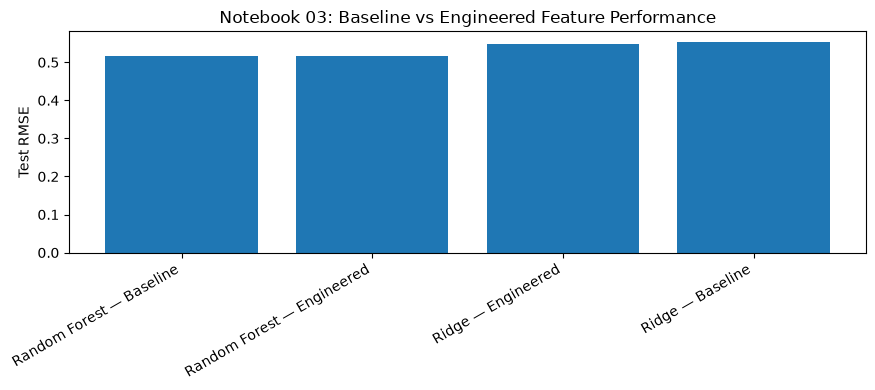

In [223]:

# Visual comparison of test RMSE.

plot_data = model_comparison_df.copy()
plot_data["experiment"] = (
    plot_data["model"]
    + " — "
    + plot_data["feature_set"]
)

plt.figure(figsize=(9, 4))
plt.bar(
    plot_data["experiment"],
    plot_data["test_rmse"],
)
plt.ylabel("Test RMSE")
plt.title("Notebook 03: Baseline vs Engineered Feature Performance")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()



## 17. Permutation Importance (WORK IN PROGRESS)

Permutation importance is computed on the best engineered-feature experiment. It measures how much test RMSE worsens when each input feature is randomly shuffled.


In [226]:
# Continuing research (Work in progress)

engineered_experiments = model_comparison_df.query(
    "feature_set == 'Engineered'"
).copy()

best_engineered_row = engineered_experiments.iloc[0]
best_engineered_model_name = best_engineered_row["model"]

if best_engineered_model_name == "Ridge":
    best_engineered_search = ridge_searches["Engineered"]
else:
    best_engineered_search = random_forest_searches["Engineered"]

X_test_engineered = model_data.loc[
    test_index,
    engineered_features,
]

y_test = y.loc[test_index]

importance_result = permutation_importance(
    estimator=best_engineered_search.best_estimator_,
    X=X_test_engineered,
    y=y_test,
    scoring="neg_root_mean_squared_error",
    n_repeats=20,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

permutation_importance_df = pd.DataFrame(
    {
        "feature": engineered_features,
        "importance_mean": importance_result.importances_mean,
        "importance_std": importance_result.importances_std,
    }
).sort_values(
    "importance_mean",
    ascending=False,
).reset_index(drop=True)

print("Best engineered-feature model:", best_engineered_model_name)
display(permutation_importance_df.head(20))


Best engineered-feature model: Random Forest


,feature,importance_mean,importance_std
0,popular_shelf_count,1.501827e-02,8.336515e-03
1,series_count,4.920309e-03,1.305913e-03
2,log1p_text_reviews_count,2.320949e-03,8.763986e-04
3,publication_day,2.291242e-03,8.086356e-04
4,text_reviews_count,2.194073e-03,9.496924e-04
5,language_code_frequency,1.451939e-03,1.582295e-03
6,edition_age^2,1.238499e-03,1.143234e-03
7,language_code_frequency_ratio,1.224852e-03,1.500090e-03
8,metadata_completeness_count,1.022343e-03,9.199077e-04
9,edition_age_x_log_ratings,7.374802e-04,1.482128e-03


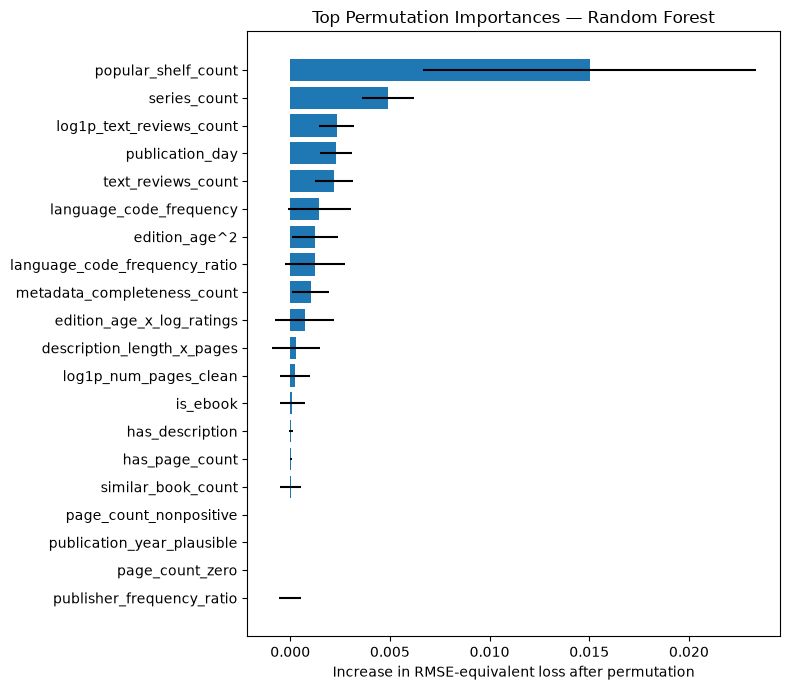

In [233]:
# Visualize features

top_importance = permutation_importance_df.head(20).sort_values(
    "importance_mean",
    ascending=True,
)

plt.figure(figsize=(8, 7))
plt.barh(
    top_importance["feature"],
    top_importance["importance_mean"],
    xerr=top_importance["importance_std"],
)
plt.xlabel("Increase in RMSE-equivalent loss after permutation")
plt.title(
    f"Top Permutation Importances — {best_engineered_model_name}"
)
plt.tight_layout()
plt.show()


## 18. Feature Lineage and Retention Recommendations

In [243]:

# Add modeling evidence to the Iteration 1 inventory.

feature_lineage_df = inventory_df.copy()

feature_lineage_df = feature_lineage_df.merge(
    permutation_importance_df,
    on="feature",
    how="left",
)

feature_lineage_df["importance_mean"] = (
    feature_lineage_df["importance_mean"]
    .fillna(0.0)
)

feature_lineage_df["importance_std"] = (
    feature_lineage_df["importance_std"]
    .fillna(0.0)
)

positive_importance = feature_lineage_df.loc[
    feature_lineage_df["importance_mean"] > 0,
    "importance_mean",
]

if len(positive_importance) > 0:
    high_importance_threshold = positive_importance.quantile(0.75)
else:
    high_importance_threshold = 0.0


def retention_recommendation(row):

    if row["unique_values"] <= 1:
        return "DROP"

    if row["feature"] == TARGET:
        return "TARGET"

    if row["importance_mean"] >= high_importance_threshold:
        return "KEEP"

    if row["importance_mean"] > 0:
        return "CONSIDER"

    if row["family"] in {
        "Log",
        "Polynomial",
        "Interaction",
        "Composite",
        "Frequency",
    }:
        return "REVIEW"

    return "CONSIDER"


feature_lineage_df["recommendation"] = (
    feature_lineage_df.apply(
        retention_recommendation,
        axis=1,
    )
)

feature_lineage_df = feature_lineage_df.sort_values(
    [
        "recommendation",
        "importance_mean",
    ],
    ascending=[True, False],
).reset_index(drop=True)

display(
    feature_lineage_df[
        [
            "feature",
            "family",
            "dtype",
            "missing_rate",
            "unique_values",
            "importance_mean",
            "importance_std",
            "recommendation",
        ]
    ].head(30)
)


,feature,family,dtype,missing_rate,unique_values,importance_mean,importance_std,recommendation
0,language_code_frequency,Frequency,int64,0.0000,29,1.451939e-03,1.582295e-03,CONSIDER
1,edition_age^2,Polynomial,float64,0.0000,83,1.238499e-03,1.143234e-03,CONSIDER
2,language_code_frequency_ratio,Frequency,double[pyarrow],0.0000,29,1.224852e-03,1.500090e-03,CONSIDER
3,metadata_completeness_count,Composite,int64,0.0000,6,1.022343e-03,9.199077e-04,CONSIDER
4,edition_age_x_log_ratings,Interaction,float64,0.2560,1882,7.374802e-04,1.482128e-03,CONSIDER
5,description_length_x_pages,Interaction,float64,0.3270,2956,2.826213e-04,1.216591e-03,CONSIDER
6,log1p_num_pages_clean,Log,float64,0.3270,621,2.392298e-04,7.655892e-04,CONSIDER
7,is_ebook,Original,boolean,0.0000,2,1.118698e-04,6.415604e-04,CONSIDER
8,has_description,Original,bool,0.0000,2,4.438630e-05,8.642235e-05,CONSIDER
9,has_page_count,Original,bool,0.0000,2,2.675955e-05,6.317722e-05,CONSIDER


In [246]:
# Save results to keep track for the longer term R&D 

lineage_output_path = (
    REPORTS / "feature_lineage_v1.csv"
).resolve()

importance_output_path = (
    REPORTS / "permutation_importance_v1.csv"
).resolve()

feature_lineage_df.to_csv(
    lineage_output_path,
    index=False,
)

permutation_importance_df.to_csv(
    importance_output_path,
    index=False,
)

print("Feature lineage:", lineage_output_path)
print("Permutation importance:", importance_output_path)


Feature lineage: /Users/rt-mac/Desktop/Project/ProjectA/semantic_book_intelligence/reports/feature_lineage_v1.csv
Permutation importance: /Users/rt-mac/Desktop/Project/ProjectA/semantic_book_intelligence/reports/permutation_importance_v1.csv



## 19. Automated Findings Summary

Interpret these results as evidence about the representation—not as final product-model performance.


In [252]:

best_overall = model_comparison_df.iloc[0]

ridge_baseline = ridge_results_df.query(
    "feature_set == 'Baseline'"
).iloc[0]

ridge_engineered = ridge_results_df.query(
    "feature_set == 'Engineered'"
).iloc[0]

forest_baseline = random_forest_results_df.query(
    "feature_set == 'Baseline'"
).iloc[0]

forest_engineered = random_forest_results_df.query(
    "feature_set == 'Engineered'"
).iloc[0]


def percent_change(old_value, new_value):
    return 100 * (new_value - old_value) / old_value


ridge_rmse_change = percent_change(
    ridge_baseline["test_rmse"],
    ridge_engineered["test_rmse"],
)

forest_rmse_change = percent_change(
    forest_baseline["test_rmse"],
    forest_engineered["test_rmse"],
)

print(
    f"Best experiment: {best_overall['model']} "
    f"with {best_overall['feature_set']} features."
)

print(
    f"Best test RMSE: {best_overall['test_rmse']:.4f}; "
    f"MAE: {best_overall['test_mae']:.4f}; "
    f"R²: {best_overall['test_r2']:.4f}."
)

print(
    f"Ridge engineered-feature RMSE change versus baseline: "
    f"{ridge_rmse_change:+.2f}%."
)

print(
    f"Random Forest engineered-feature RMSE change versus baseline: "
    f"{forest_rmse_change:+.2f}%."
)

print("\nTop five permutation-important features:")
display(
    permutation_importance_df.head(5)
)


Best experiment: Random Forest with Baseline features.
Best test RMSE: 0.5157; MAE: 0.3581; R²: 0.1486.
Ridge engineered-feature RMSE change versus baseline: -0.90%.
Random Forest engineered-feature RMSE change versus baseline: +0.11%.

Top five permutation-important features:


,feature,importance_mean,importance_std
0,popular_shelf_count,0.015018,0.008337
1,series_count,0.004920,0.001306
2,log1p_text_reviews_count,0.002321,0.000876
3,publication_day,0.002291,0.000809
4,text_reviews_count,0.002194,0.000950



# Iteration 2 Checkpoint

After running this revision, my goal was to review:

1. Whether engineered features improve Ridge test RMSE.
2. Whether engineered features improve Random Forest test RMSE.
3. Whether train/CV/test performance suggests overfitting.
4. Which engineered families appear among the top permutation-important features.
5. Whether popularity-related variables dominate prediction of average rating.
6. Which features should be kept, reviewed, or dropped before `book_features_v2`.

Artifacts produced:

- `data/processed/book_features_v1.parquet`
- `reports/feature_inventory_v1.csv`
- `reports/notebook03_model_comparison.csv`
- `reports/permutation_importance_v1.csv`
- `reports/feature_lineage_v1.csv`

## Key Findings so far (To be continued in the next Notebook)
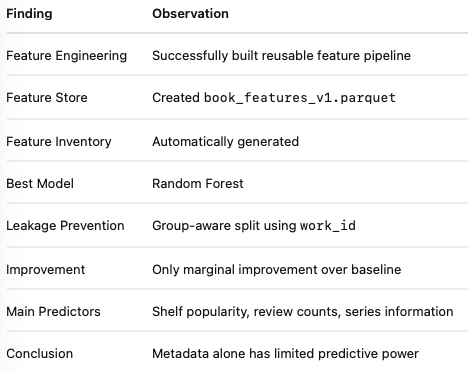

